# Fixed Boundary Conditions

First we import some packages

In [1]:
import numpy as np
import pyPolygon as pp
from matplotlib import pyplot as plt

Then we make our packing. We also make sure this demo is repeatable, so we set a random seed.

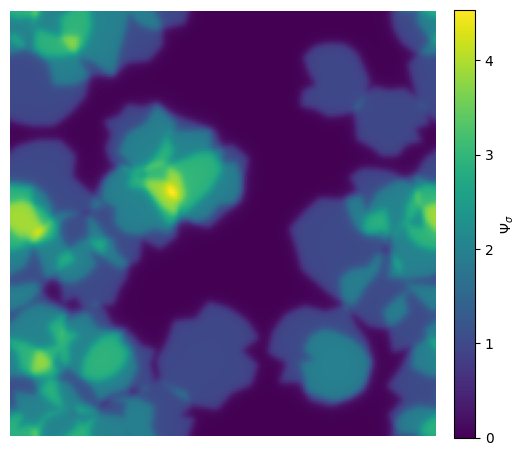

In [2]:
packing = pp.Model(N = 32, n = 16, seed = 42)
packing.generateEquilateralPolygons(phi = 1.0, kappa = 4.0)
packing.setBiPerimeter() # make all the squares equal in size
# We then set our fixed boundary conditions
packing.setModelType("mollified")
packing.setMollification(sigma = 1e-2)
packing.draw(indicatorColorMap = 'viridis')
plt.show()

Based on the name of the notebook, you probably realize that we don't actually want periodic or free boundary conditions. However, of the boundary conditions that are implemented (periodic and free), free is much easier to deal with. We make soft boundary conditions by putting a 1x1 square over the whole boundary and making it suck the squares into it.

However, just putting a square over the boundary would shove polygons out and we want to pull polygons in. Therefore, we make our boundary square clockwise:

(0,0), (0,1), (1,1), (1,0). 

But again this isn't quite right because now any amount of overlapping area between a cw and ccw polygon is negative. Instead, we want the area to be 0 when the polygon is inside the boundary square and the area that is outside should be positive. The simple fix is to just add the area of the polygon to the (negatively-signed) overlapping area. 

We then pin these vertices. We do this by hand as in the following:

<Axes: >

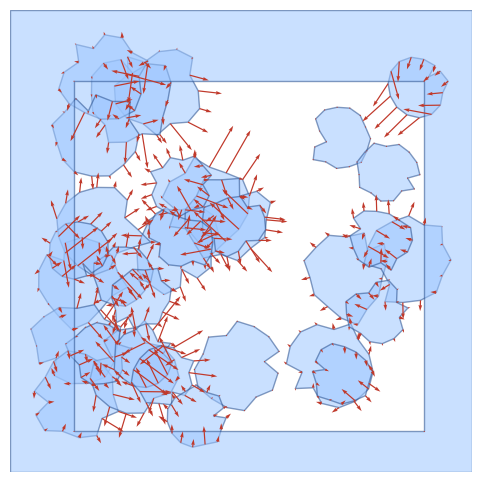

In [3]:
vertices = np.array([[0, 0], [0, 1], [1, 1], [1, 0]])
packing.addShape(vertices)
packing.pinVertices(np.arange(packing.getNumVertices())[-4:])
# And then we set our boundary conditions to "fixed"
packing.setBoundaryConditions("fixed") # This automatically assumes the final polygon is the boundary
# We also want to constrain the vertices:
packing.setConstraints()
# Now we can proceed with finding the forces and drawing them as arrows
packing.initForceEnergy()
packing.calcForceEnergy()
forces = packing.getForces()
packing.draw(forces = forces) # Draw knows to draw this as if it has free boundaries and to draw the outside the square's area rather than the insides

We always make sure the energy contributions is internally changed for this final square when setting the boundary conditions to "fixed"

Now we can try minimizing this with FIRE. Let's start with 10,000 steps and show a progress bar

FIRE (constrained):   0%|          | 0/10000 [00:00<?, ?it/s]

This was after 417 steps.


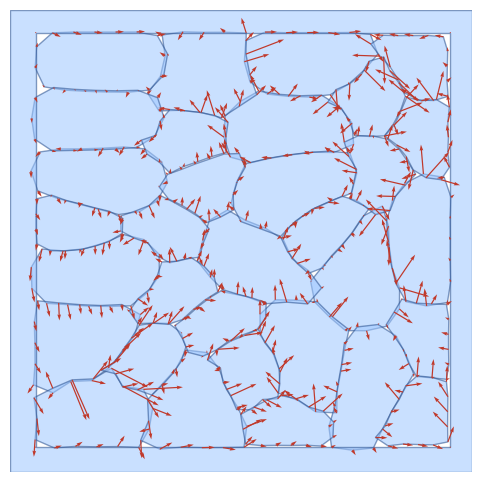

In [4]:
steps = packing.minimizeFIRE(maxSteps = 10_000, fThreshold = 1e-3, progressBar = True)
packing.draw(forces = packing.getForces())
print("This was after " + str(steps) + " steps.")

From here we can minimize with CG to polish

CG (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

The maximum unbalanced force is 3.478034023609722e-07


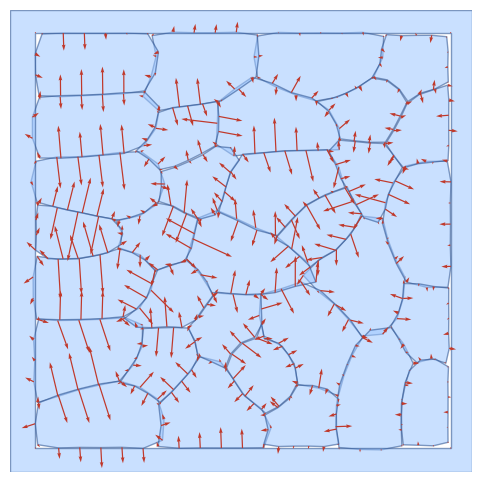

In [5]:
packing.minimizeCG(maxSteps = 1_000, fThreshold = 1e-9)
packing.draw(forces = packing.getForces())
print("The maximum unbalanced force is " + str(packing.getMaxUnbalancedForce()))